In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

folder_path = r"D:\OneDrive\Trading\Market Making\data\runs\run_20260829_063459"

snapshots = pd.read_parquet(os.path.join(folder_path, "snapshots.parquet"))
snapshots

,ts,trade_latency,depth_latency,exchange_latency,symbol,mid,mid_tick,microprice,microprice_dev,microprice_error,...,ask_delta,quote_churn,future_mid_100ms,future_return_100ms,future_mid_500ms,future_return_500ms,future_mid_1000ms,future_return_1000ms,future_mid_5000ms,future_return_5000ms
0,1787985301844,0,40,0,PEPEUSDT,0.000004,363,0.000004,-2.925525e-10,2.925525e-10,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0
1,1787985301944,0,42,0,PEPEUSDT,0.000004,363,0.000004,-2.925525e-10,2.925525e-10,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0
2,1787985304644,0,50,0,PEPEUSDT,0.000004,363,0.000004,-2.925525e-10,2.925525e-10,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0
3,1787985305444,0,39,0,PEPEUSDT,0.000004,363,0.000004,-2.809600e-10,2.809600e-10,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0
4,1787985305744,0,40,0,PEPEUSDT,0.000004,363,0.000004,-2.818604e-10,2.818604e-10,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23085,1787994879244,38,39,0,PEPEUSDT,0.000004,362,0.000004,2.557403e-09,-2.557403e-09,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,NaN,NaN
23086,1787994879844,38,39,0,PEPEUSDT,0.000004,362,0.000004,2.526454e-09,-2.526454e-09,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,NaN,NaN
23087,1787994880944,38,44,0,PEPEUSDT,0.000004,362,0.000004,2.525616e-09,-2.525616e-09,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,NaN,NaN
23088,1787994881245,38,40,0,PEPEUSDT,0.000004,362,0.000004,2.525616e-09,-2.525616e-09,...,0.0,0.0,0.000004,0.0,0.000004,0.0,0.000004,0.0,NaN,NaN


In [ ]:
"""
With struct delta

Your structural reservation is:
struct_reservation = mid + struct_delta

Then train: y = log(future_mid / struct_reservation)

df[f"y_{h}ms"] = np.log(df[f"future_mid_{h}ms"] / (df["mid"] + df["struct_delta"])) # log return with struct delta

against:
x = (microprice - mid) / mid

So:
y^ = a + βx

Then:
log(future_mid / struct_reservation) = a + β((microprice - mid) / mid)

Exponentiate:
future_mid = (mid + struct_delta) exp(a + β((microprice - mid) / mid))

Therefore:
micro_signal_delta = (mid + struct_delta)(exp(a + βx) - 1)

Implementation becomes:
double predict_micro_delta(const Features& features, double struct_delta){
    double struct_reservation = features.mid + struct_delta;

    double micro_log_return = intercept + beta * (features.microprice_dev / features.mid);

    double predicted_future = struct_reservation * exp(micro_log_return);

    return predicted_future - struct_reservation;
}

"""

In [2]:
"""
“Is microprice a statistically and economically meaningful estimator of future mid-price changes at horizon h?”

"""

df = snapshots

horizons = [100, 500, 1000, 5000]

df["micro_signal"] = (df["microprice_dev"]) / df["mid"] # expected return using microprice

for h in horizons:
    df[f"y_{h}ms"] = (df[f"future_mid_{h}ms"] - df["mid"]) / df["mid"] # future mid return without struct delta
    # df[f"y_{h}ms"] = np.log(df[f"future_mid_{h}ms"] / (df["mid"] + df["struct_delta"])) # log return with struct delta

df = df.dropna()

In [5]:
"""
(A) Pearson IC (what you are using)

captures linear relationship
sensitive to outliers
tells you “how proportional is the move?”

"""

def ic(pred, y):
    return np.corrcoef(pred, y)[0,1]

"""
(B) Rank IC (Spearman IC)

ignores magnitude
only cares about ordering
much more realistic in microstructure

In HFT, Rank IC is often more meaningful than IC.

"""

def rank_ic(pred, y):
    return spearmanr(pred, y).statistic

results = {}
models = {}

for h in horizons:

    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y) #filter out all nan values
    x = x[mask].reshape(-1, 1)
    y = y[mask]

    reg = LinearRegression()
    reg.fit(x, y)

    beta = reg.coef_[0]
    intercept = reg.intercept_

    pred = reg.predict(x)

    ic_val = np.corrcoef(x.flatten(), y)[0, 1]
    rank_ic_val = spearmanr(x.flatten(), y).statistic

    hit_rate = (np.sign(x.flatten()) == np.sign(y)).mean()

    pnl_proxy = np.mean(x.flatten() * y)
    pnl_std = np.std(x.flatten() * y)

    sharpe_proxy = pnl_proxy / (pnl_std + 1e-12)

    models[h] = {
        "model": reg,
        "beta": beta,
        "intercept": intercept,
        "ic": ic_val,
        "rank_ic": rank_ic_val
    }

    results[h] = {
        "Residual_IC": ic_val,
        "Residual_Rank_IC": rank_ic_val,
        "HitRate": hit_rate,
        "PnLProxy": pnl_proxy,
        "SharpeProxy": sharpe_proxy,
    }

pd.set_option('display.float_format', '{:.18f}'.format)
microprice_residual_results_df = pd.DataFrame(results)
microprice_residual_results_df

,100,500,1000,5000
Residual_IC,0.128704427003873328,0.200377136729765232,0.273459759956077131,0.415556606239752213
Residual_Rank_IC,0.090480557979081735,0.145067881798166098,0.200006305656852262,0.330116316115700636
HitRate,0.003249566724436742,0.008578856152512998,0.016291161178509532,0.048916811091854417
PnLProxy,0.000000009314103299,0.000000023495909633,0.000000043536224017,0.000000116043702841
SharpeProxy,0.054747433219794583,0.088531466840903766,0.121143631693213891,0.206747823463759389


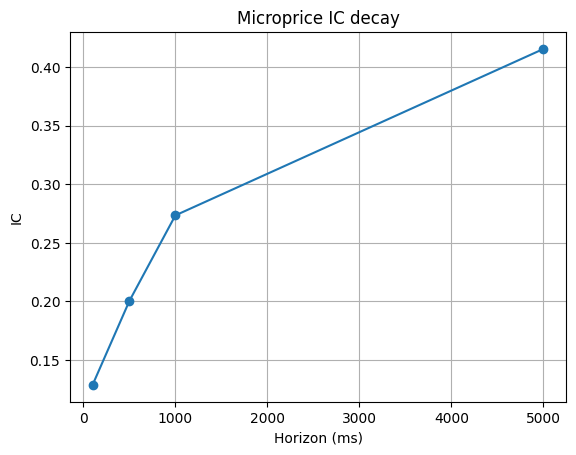

In [4]:
ic_curve = []

for h in horizons:
    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y)

    ic_curve.append(ic(x[mask], y[mask]))

plt.plot(horizons, ic_curve, marker="o")
plt.title("Microprice IC decay")
plt.xlabel("Horizon (ms)")
plt.ylabel("IC")
plt.grid()
plt.show()

In [7]:
df["signal_bin"] = pd.qcut(
    df["micro_signal"],
    20,
    duplicates="drop"
)

df.groupby("signal_bin")["y_5000ms"].agg(["mean", "median", "count"])

,mean,median,count
signal_bin,,,
"(-0.00234, -0.000284]",-0.000941,0.0,1160
"(-0.000284, -0.000217]",-0.000165,0.0,1150
"(-0.000217, -0.000146]",-0.000112,0.0,1155
"(-0.000146, -7.33e-05]",-0.000045,0.0,1160
"(-7.33e-05, -3.99e-05]",-0.000019,0.0,1146
"(-3.99e-05, -1.05e-05]",-0.000067,0.0,1154
"(-1.05e-05, 9.05e-06]",0.000000,0.0,1154
"(9.05e-06, 2.64e-05]",0.000002,0.0,1153
"(2.64e-05, 5.71e-05]",0.000007,0.0,1157


In [8]:
"""
So your model is approximately:

future_return_100ms
≈
5.519918083330967 x micro_signal

You can probably ignore the intercept.

No Struct Delta
You fit
y = (future_mid - mid) / mid

against
x = (microprice - mid) / mid

so your model is
y^ = βx + a.

Substituting,
(future_mid - mid) / mid = a + β((microprice - mid) / mid).

Rearranging,
future_mid = mid + mid(a + β((microprice - mid) / mid)).

Therefore the predicted change in price is
micro_signal Δ = mid(a + β((microprice - mid) / mid)).

"""

print("intercept:", models[5000]["intercept"])
print("beta:", models[5000]["beta"])
print("ic:", models[5000]["ic"])

intercept: -9.686619690830691e-05
beta: 0.5579663725050954
ic: 0.4155566062397522


In [ ]:
# artifact = {
#     "model_name": "micro_signal",
#     "target": "(microprice - mid / mid)",
#     "horizon_ms": 100,
#     "intercept": models[100]["intercept"],
#     "beta": models[100]["beta"],
#     "ic": models[100]["ic"]
# }

# joblib.dump(artifact, "data/micro_signal_model_4.pkl")

['data/micro_signal_model_4.pkl']

In [9]:
def export_micro_signal(model_name, target, horizon_ms):
    artifact = {
        "model_name": model_name,
        "target": target,
        "horizon_ms": horizon_ms,
        "intercept": float(models[horizon_ms]["intercept"]),
        "beta": float(models[horizon_ms]["beta"]),
        "ic": float(models[horizon_ms]["ic"]),
        "rank_ic": float(models[horizon_ms]["rank_ic"])
    }

    with open(f"data/{model_name}.json", "w") as f:
        json.dump(artifact, f, indent=4)

    print(f"['data/{model_name}.json']")

export_micro_signal(model_name="micro_signal_model_pepe", target="(microprice - mid) / mid", horizon_ms=5000)

['data/micro_signal_model_pepe.json']
